**Full environment, dataset, and code setup**

In [1]:
# =========================================================
# CELL 1 - FULL SETUP COLAB
# =========================================================
# ===== CHANGE DIRECTORY (auto-detect Colab / Kaggle) =====
import os
BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else "/content"
%cd $BASE
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB
# =========================================================

!git clone --branch main --single-branch https://github.com/ThongLuc2k3/PGA_Unet2D.git

# =========================================================
# DOWNLOAD DATASET ZIP FROM GOOGLE DRIVE
# =========================================================

!gdown --id 1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -q dataset_BTXRD.zip

# =========================================================
# INSPECT DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_BTXRD

# =========================================================
# COPY DATASET INTO THE PROJECT
# =========================================================

!mv dataset_BTXRD PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/

# =========================================================
# ENTER THE PROJECT DIRECTORY
# =========================================================

%cd PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown

print("\nSETUP DONE!")

/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4295, done.
remote: Counting objects: 100% (532/532), done.
remote: Compressing objects: 100% (254/254), done.
remote: Total 4295 (delta 348), reused 401 (delta 277), pack-reused 3763 (from 2)
Receiving objects: 100% (4295/4295), 1.21 GiB | 37.78 MiB/s, done.
Resolving deltas: 100% (2562/2562), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx
From (redirected): https://drive.google.com/uc?id=1Ep3w8GujpCQ5Qb6nlXKxXhsCxlc3k8gx&confirm=t&uuid=839440c7-75c6-432a-81d6-74623e35e5a8
To: /kaggle/working/dataset_BTXRD.zip
100%|███████████████████████████████████████| 1.71G/1.71G [00:15<00:00, 112MB/s]

DATASET STRUCTURE:
test  

**Train**

In [2]:
# =========================================================
# TRAIN
# =========================================================

!DATASET_ROOT=dataset_BTXRD python train_attunet.py


TRAIN ATTENTION U-NET 2D | Device: cuda
Batch: 4 | MaxEpochs: 150 | LR: 0.0001 | ImgSize: 512
WeightDecay: 0.0001 | EarlyStop patience: 15
Epoch 1/150 [Train]: 100%|███████| 374/374 [01:27<00:00,  4.27it/s, loss=1.2130]
[BEST] Epoch   1 | Loss: 1.2881 | Dice: 0.0002 | IoU: 0.0001 | Pre: 0.0062 | Rec: 0.0001 | LR: 1.00e-04
Epoch 2/150 [Train]: 100%|███████| 374/374 [01:32<00:00,  4.03it/s, loss=1.1817]
Epoch   2 | Loss: 1.1618 | Dice: 0.0000 | IoU: 0.0000 | Pre: 0.0000 | Rec: 0.0000 | LR: 1.00e-04
Epoch 3/150 [Train]: 100%|███████| 374/374 [01:32<00:00,  4.05it/s, loss=1.1362]
Epoch   3 | Loss: 1.1119 | Dice: 0.0000 | IoU: 0.0000 | Pre: 0.0000 | Rec: 0.0000 | LR: 1.00e-04
Epoch 4/150 [Train]: 100%|███████| 374/374 [01:32<00:00,  4.06it/s, loss=1.0912]
[BEST] Epoch   4 | Loss: 1.0737 | Dice: 0.1744 | IoU: 0.1153 | Pre: 0.1615 | Rec: 0.3703 | LR: 1.00e-04
Epoch 5/150 [Train]: 100%|███████| 374/374 [01:31<00:00,  4.07it/s, loss=0.9920]
Epoch   5 | Loss: 1.0356 | Dice: 0.1699 | IoU: 0.1190 

**Test + Dice + IoU + BCE**

ATT_Unet2D

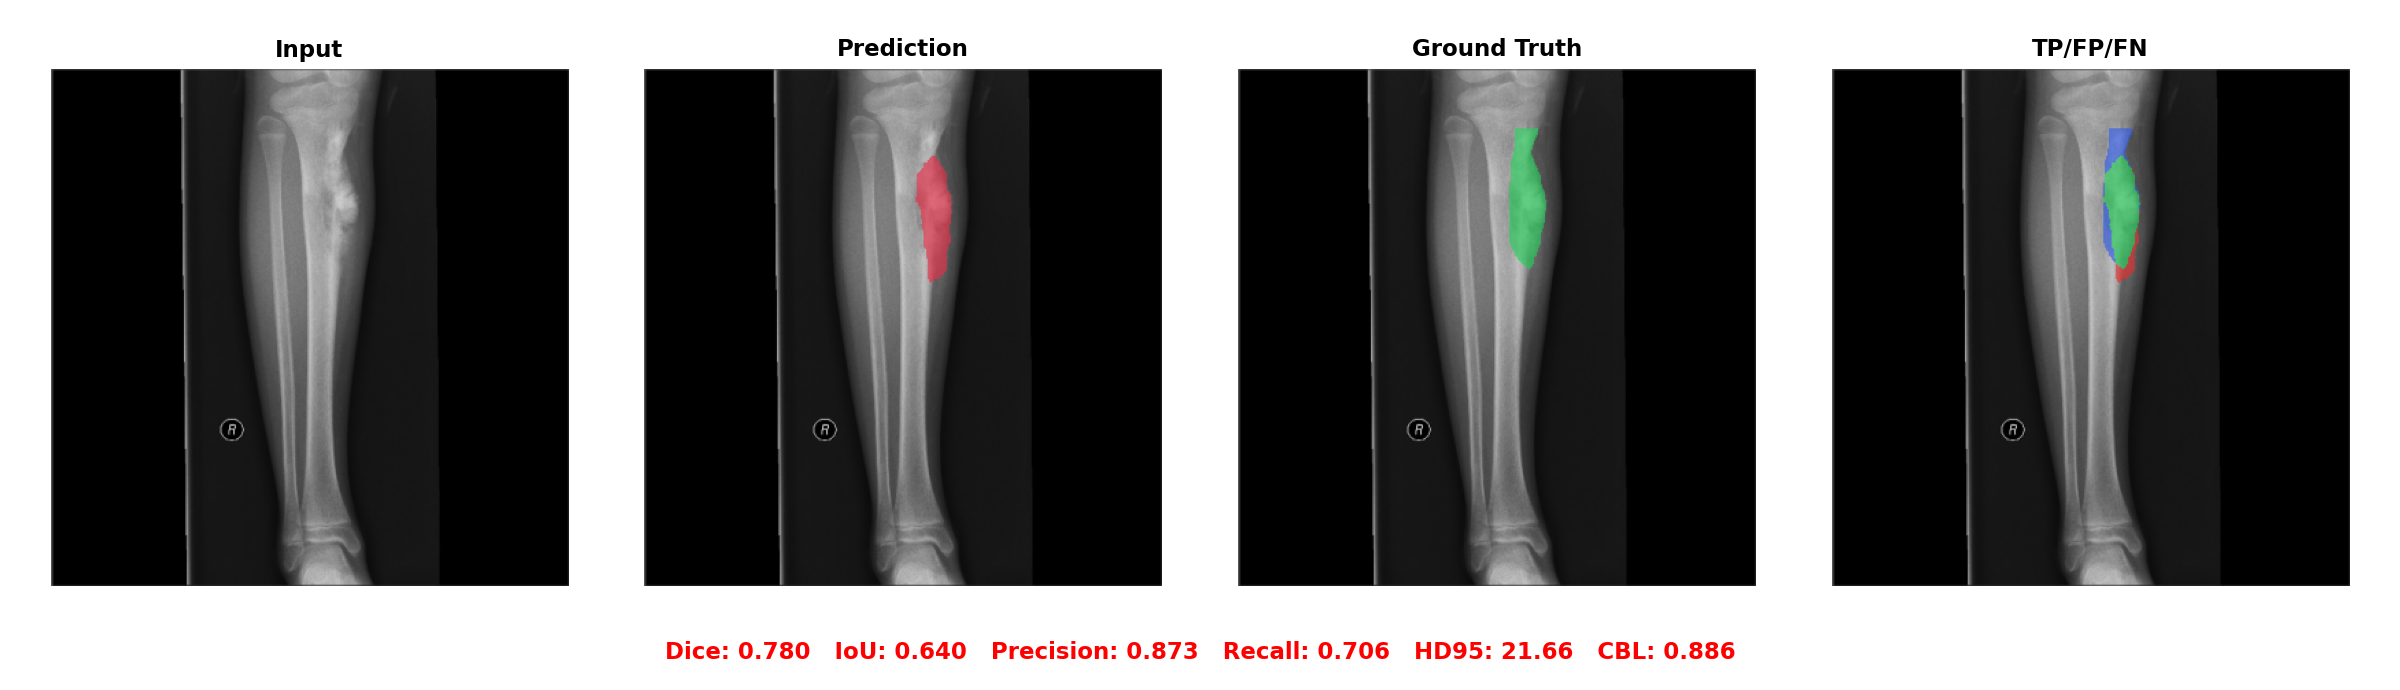

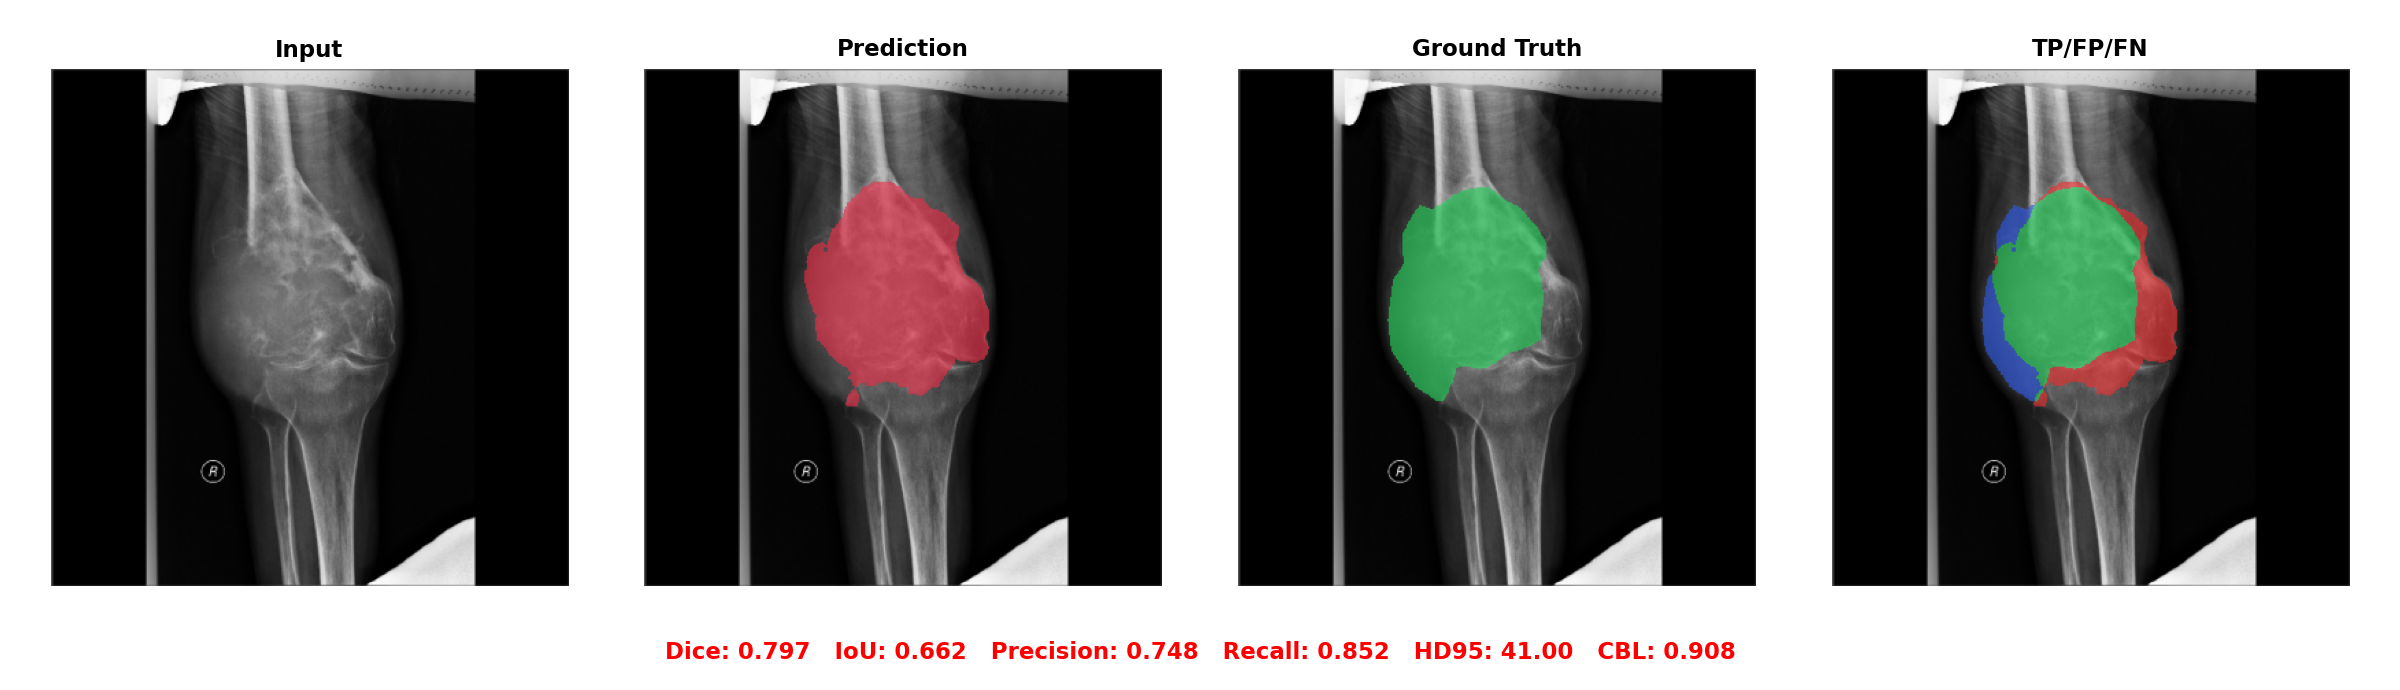

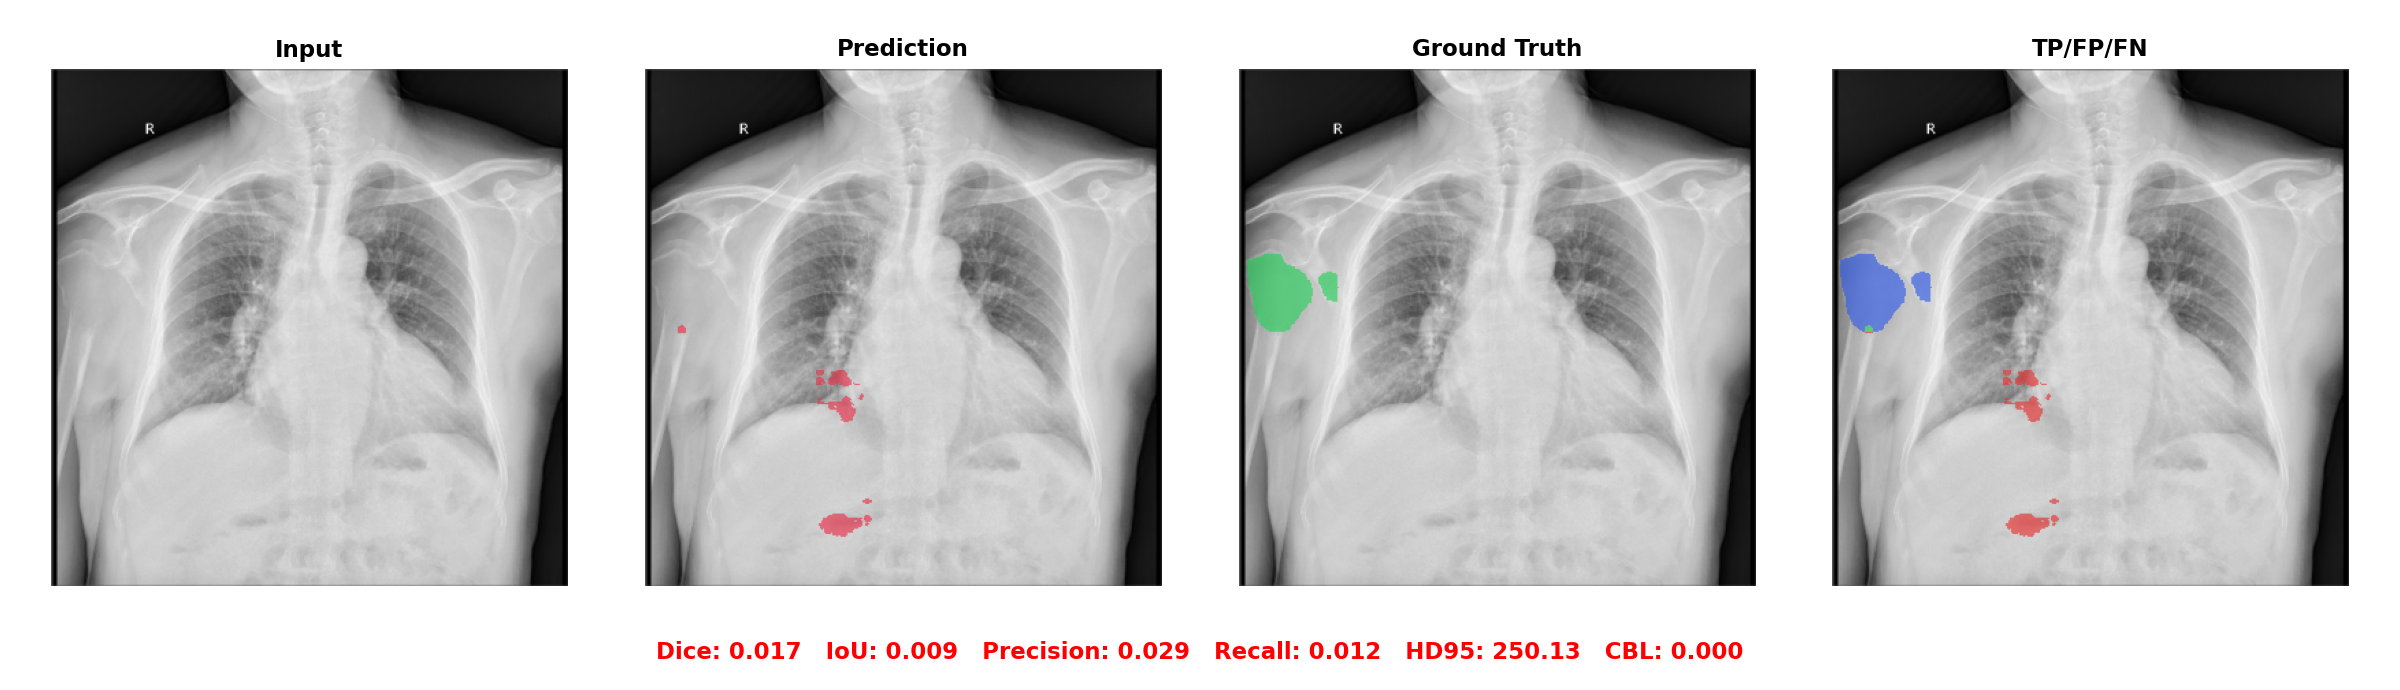

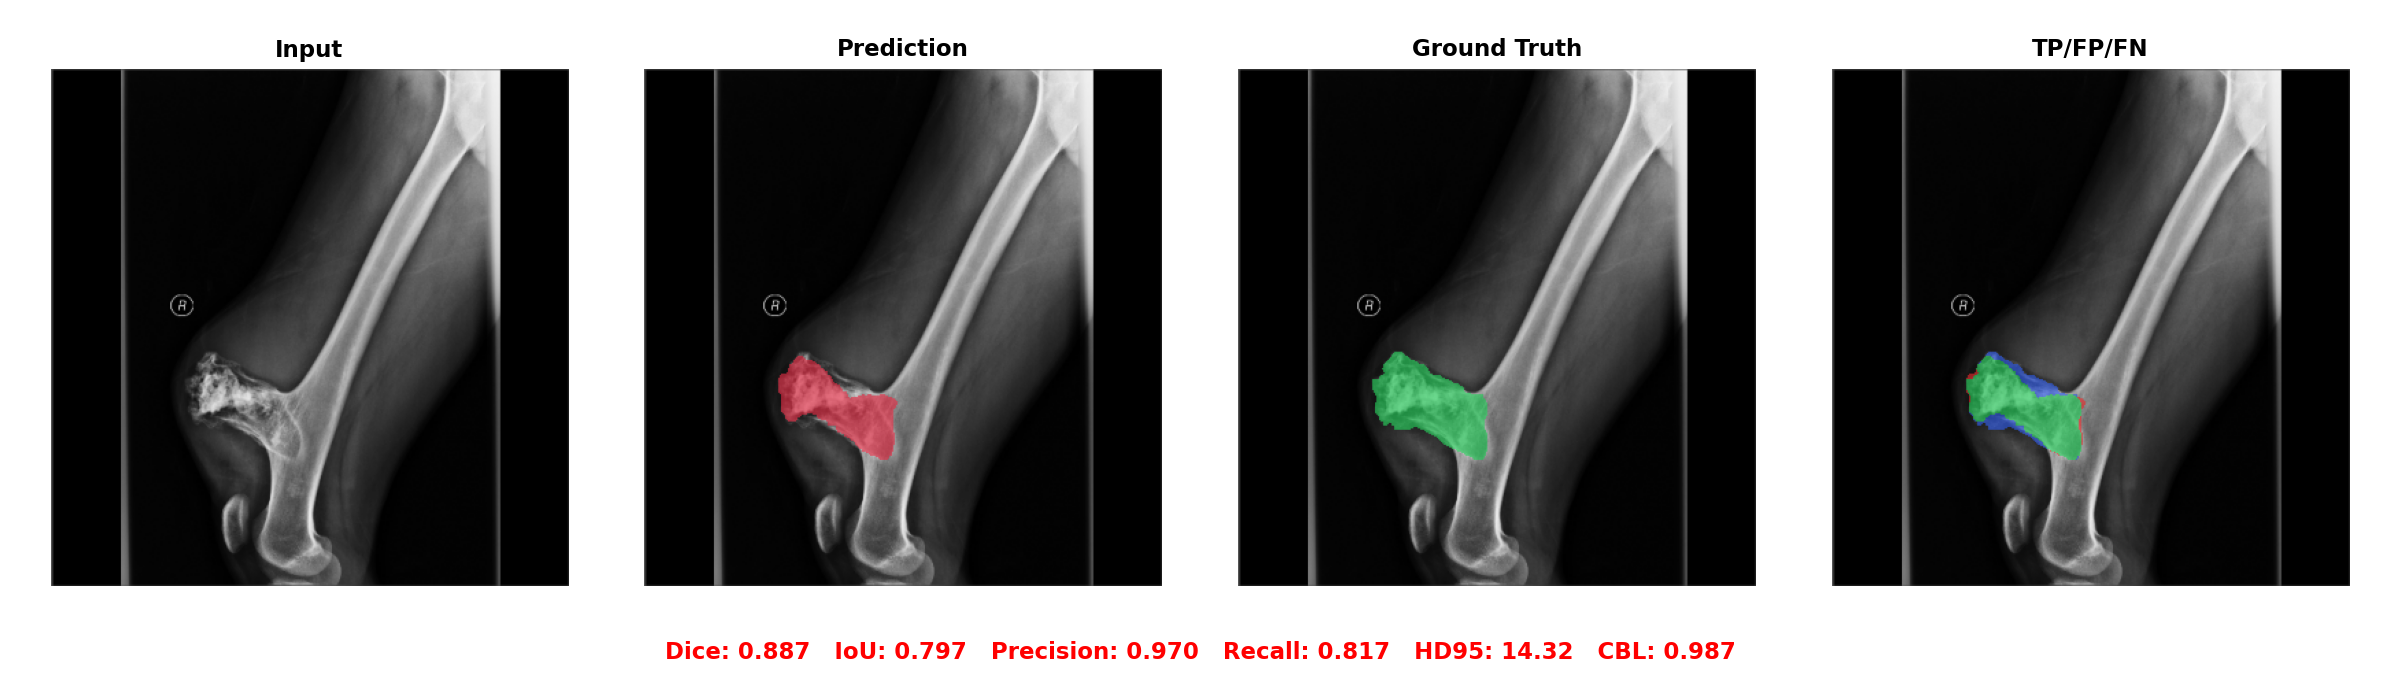

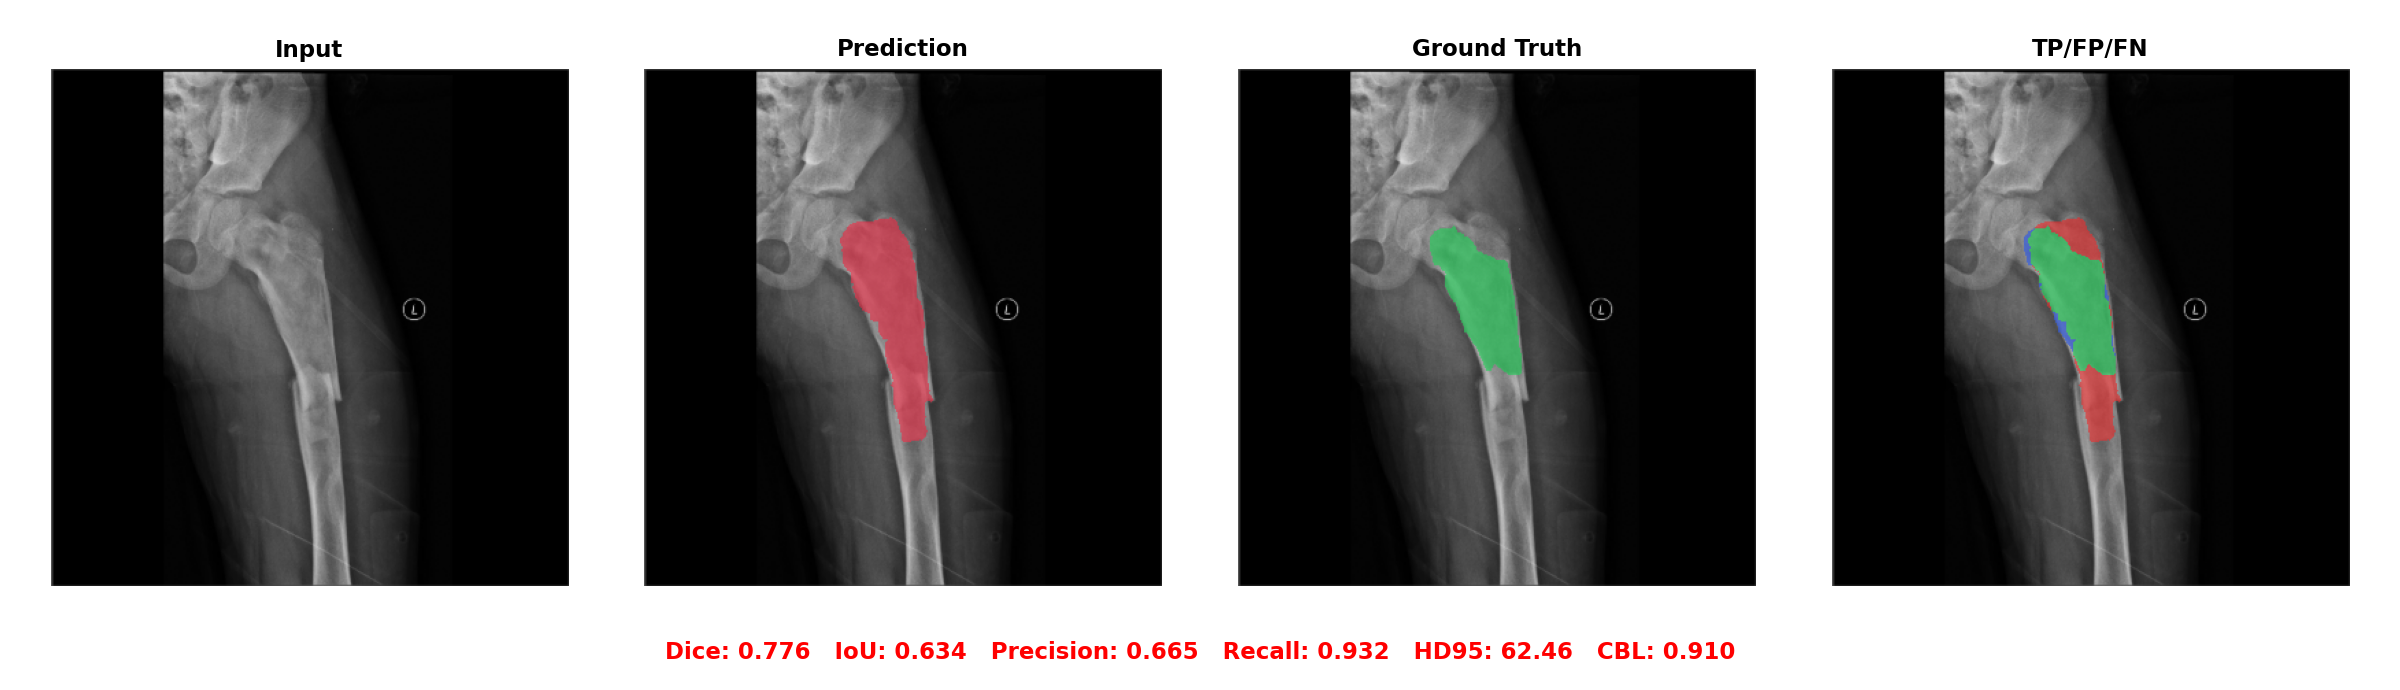

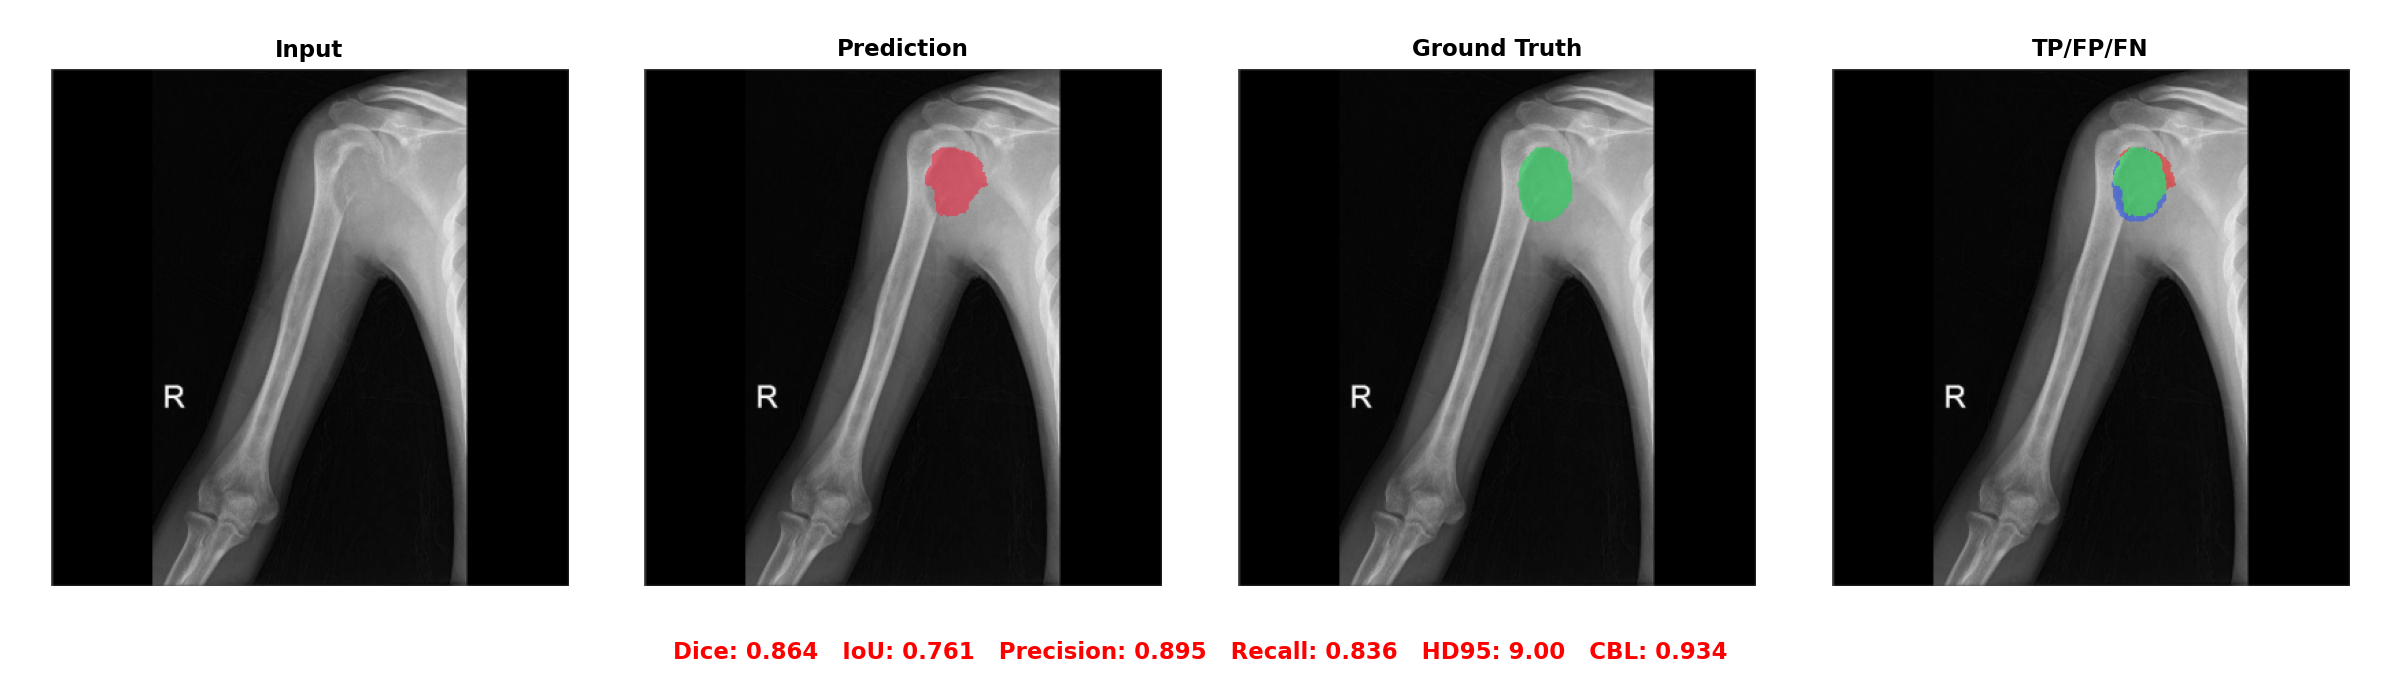

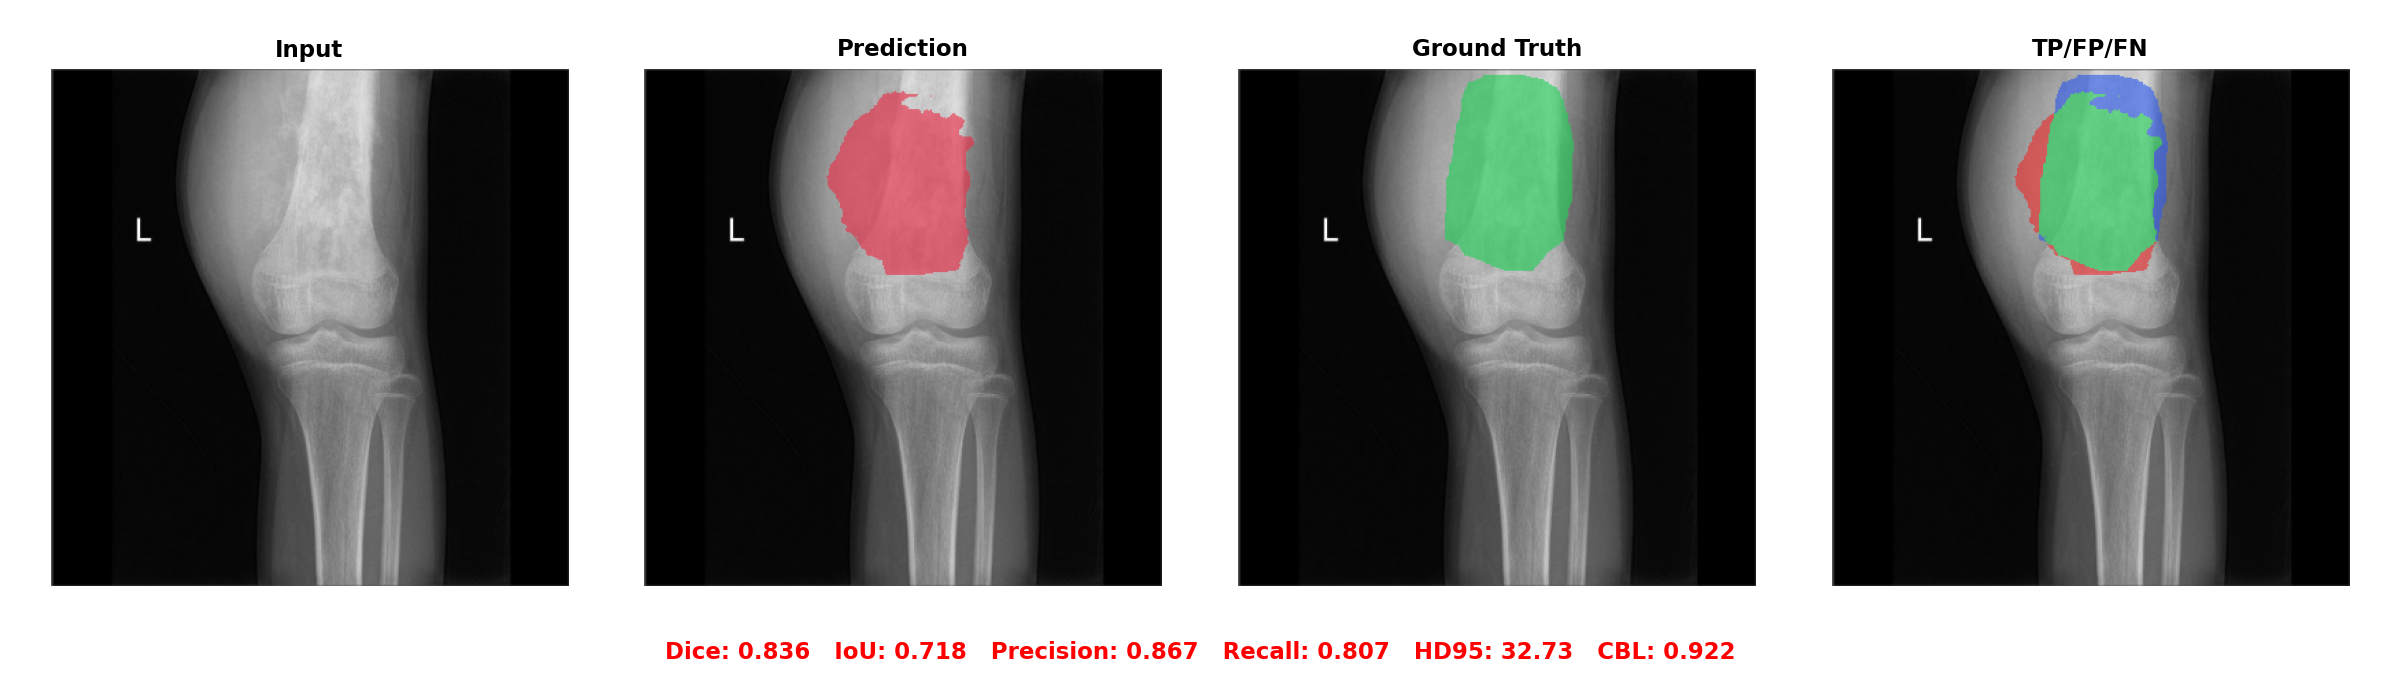

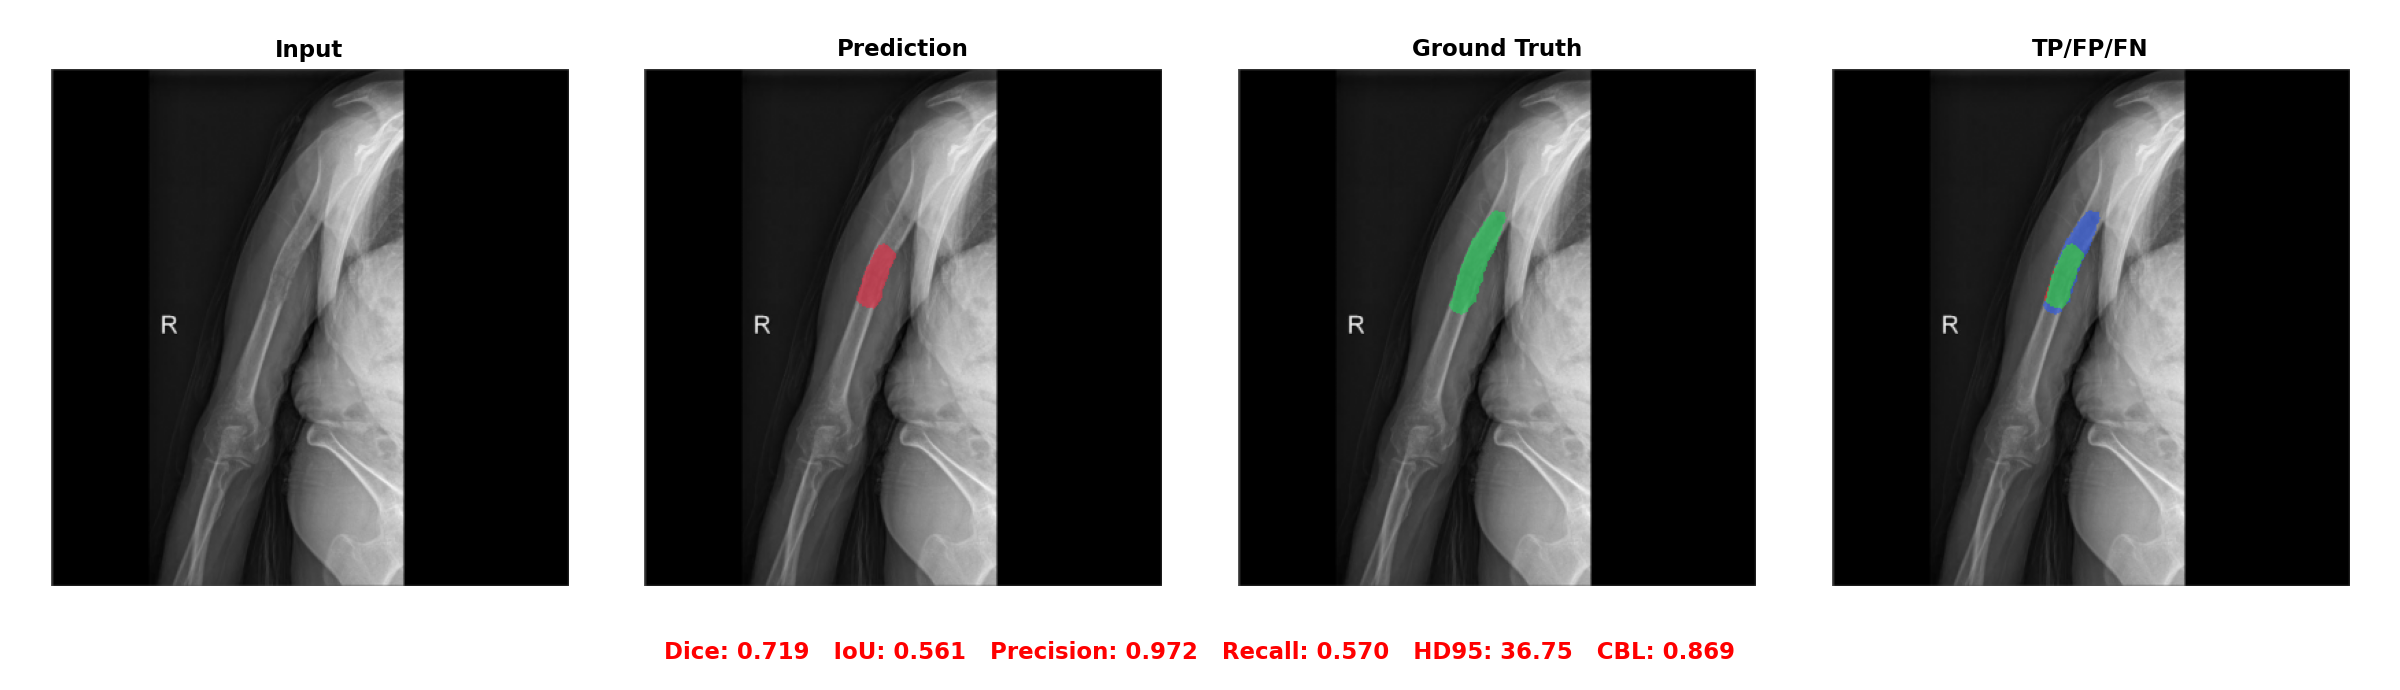

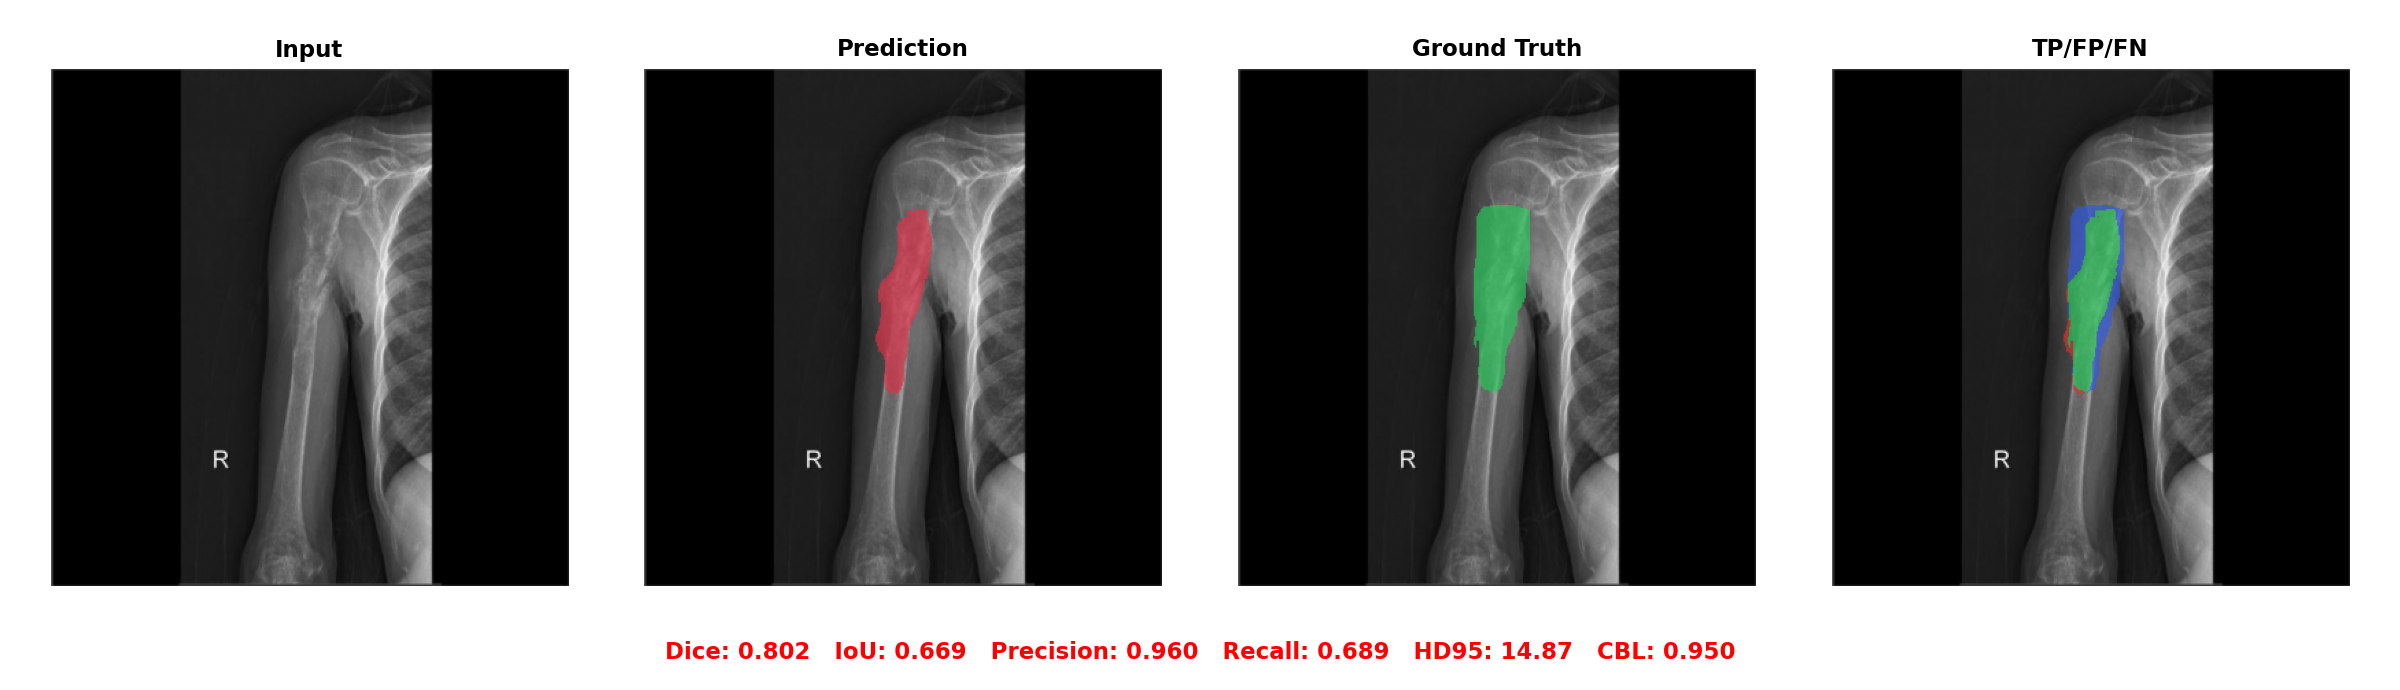

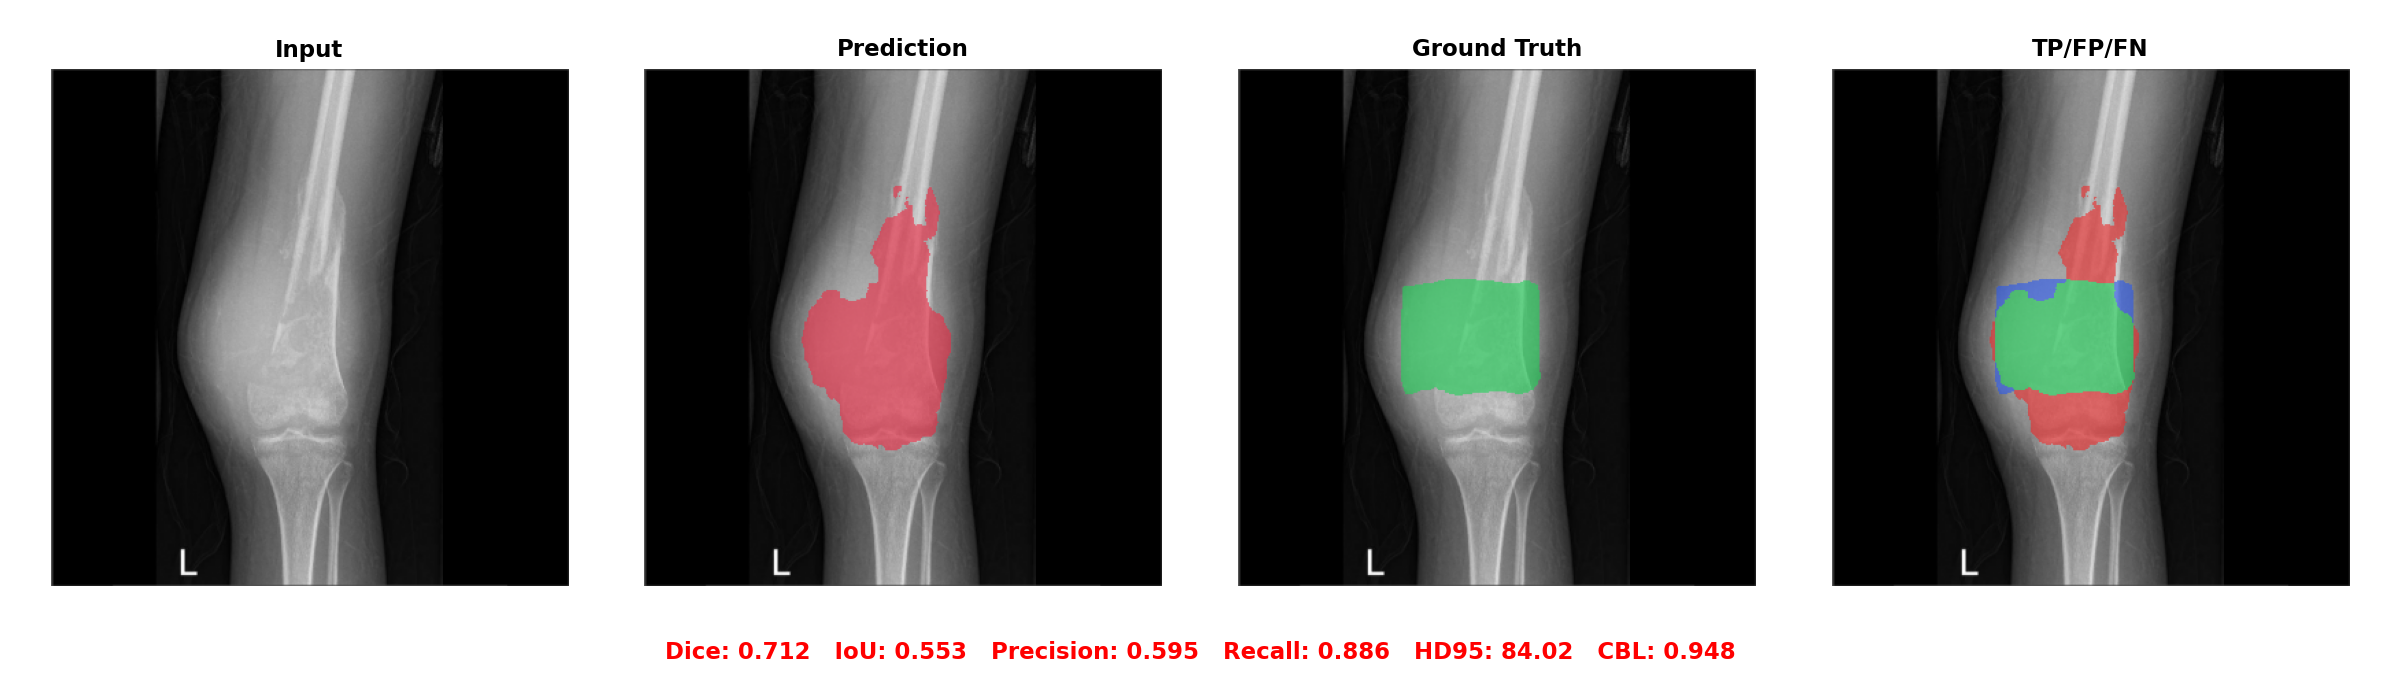

Dice,IoU,Precision,Recall,HD95 (px),CBL,N
0.516470,0.417842,0.577622,0.543354,120.43,0.619680,187



Results saved: results/attunet2d_results.csv


In [3]:
from qualitative_visualization import (export_qualitative_rows, records_for_stems,
                                           resolve_runtime_path, select_shared_stems)
# @title
# =========================================================
# TEST PHASE (ATTENTION U-NET 2D - METRICS SYNCHRONIZED WITH PROMPT-UNET)
# =========================================================

import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from scipy.ndimage import binary_erosion, distance_transform_edt
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

from models.networks.attention_unet_2D import Attention_UNet_2D

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = str(resolve_runtime_path("checkpoints/att_unet_best.pth"))
IMG_SIZE = 512

class BTXRDImageMaskDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=512, is_train=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.is_train = is_train
        image_names = sorted(f for f in os.listdir(image_dir)
                             if f.lower().endswith(('.png', '.jpg', '.jpeg')))
        mask_by_stem = {}
        for mask_name in sorted(os.listdir(mask_dir)):
            if not mask_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            stem = os.path.splitext(mask_name)[0]
            if stem in mask_by_stem:
                raise ValueError(f'Duplicate mask stem: {stem}')
            mask_by_stem[stem] = mask_name
        missing = [name for name in image_names if os.path.splitext(name)[0] not in mask_by_stem]
        if missing:
            raise FileNotFoundError(f'Missing masks for {len(missing)} images: {missing[:5]}')
        self.samples = [(name, mask_by_stem[os.path.splitext(name)[0]]) for name in image_names]
        self.images = [image_name for image_name, _ in self.samples]
        self.masks = [mask_name for _, mask_name in self.samples]

    def __len__(self):
        return len(self.samples)

    def _resize_and_pad(self, array, interpolation, pad_value=0):
        orig_h, orig_w = array.shape[:2]
        scale = min(self.img_size / orig_w, self.img_size / orig_h)
        new_w = max(1, int(round(orig_w * scale)))
        new_h = max(1, int(round(orig_h * scale)))
        resized = cv2.resize(array, (new_w, new_h), interpolation=interpolation)
        padded = np.full((self.img_size, self.img_size), pad_value, dtype=resized.dtype)
        pad_left = (self.img_size - new_w) // 2
        pad_top = (self.img_size - new_h) // 2
        padded[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized
        return padded

    def __getitem__(self, idx):
        img_name, mask_name = self.samples[idx]
        image = cv2.imread(os.path.join(self.image_dir, img_name), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        image = self._resize_and_pad(image, cv2.INTER_LINEAR, pad_value=0)
        mask = self._resize_and_pad(mask, cv2.INTER_NEAREST, pad_value=0)
        image = (image.astype(np.float32) / 255.0 - 0.5) / 0.5
        mask = (mask > 127).astype(np.float32)
        return torch.from_numpy(image).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)




def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any(): return 0.0
    if not pred.any() or not gt.any(): return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2): return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))


def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    if gt_bin.sum() == 0: return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + 1e-6
    if pred_bin.sum() == 0: return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean()-xs.mean())**2 + (yp.mean()-ys.mean())**2)
    return float(np.clip(1.0 - d/gt_diag, 0.0, 1.0))


def get_centroid(binary_map: np.ndarray):
    if binary_map.sum() == 0: return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())

model = Attention_UNet_2D(in_channels=1, n_classes=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

test_dataset = BTXRDImageMaskDataset(
    str(resolve_runtime_path("dataset_BTXRD/test/images")),
    str(resolve_runtime_path("dataset_BTXRD/test/masks")),
    img_size=IMG_SIZE, is_train=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

selection_records = [
    dict(img_name=image_name, n_samples=1)
    for image_name, _ in test_dataset.samples
]
TRAIN_SHARED_STEMS = select_shared_stems(selection_records, n_multi=5, n_single=5)
dataset_index_by_name = {image_name: idx for idx, (image_name, _) in enumerate(test_dataset.samples)}
missing_stems = [name for name in TRAIN_SHARED_STEMS if name not in dataset_index_by_name]
assert not missing_stems, f"Attention U-Net test set is missing shared stems: {missing_stems}"
SHOW_INDEX = {dataset_index_by_name[name] for name in TRAIN_SHARED_STEMS}
all_dice, all_iou, all_pre, all_rec, all_hd95, all_cbl = [], [], [], [], [], []
show_records = []
smooth = 1e-5

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        img_np = (images[0, 0].cpu().numpy() + 1) / 2.0
        gm = masks[0, 0].cpu().numpy()
        pm = preds[0, 0].cpu().numpy()
        tp = (pm * gm).sum()
        fp = (pm * (1 - gm)).sum()
        fn = ((1 - pm) * gm).sum()
        dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
        iou = (tp + smooth) / (tp + fp + fn + smooth)
        pre = tp / (tp + fp + smooth)
        rec = (tp + smooth) / (tp + fn + smooth)
        hd = calc_hd95(pm.astype(bool), gm.astype(bool))
        cbl = calc_cbl(pm.astype(bool), gm.astype(bool))
        all_dice.append(dice); all_iou.append(iou); all_pre.append(pre); all_rec.append(rec); all_hd95.append(hd)
        if cbl is not None: all_cbl.append(cbl)

        if idx in SHOW_INDEX:
            show_records.append(dict(idx=idx, img_name=test_dataset.samples[idx][0],
                                     n_samples=1,
                                     img=img_np.copy(), gt=gm.copy(), pred=pm.copy(),
                                     dice=dice, iou=iou, hd95=hd, cbl=cbl, precision=pre, recall=rec))

show_records = records_for_stems(
    show_records, TRAIN_SHARED_STEMS, context='Attention U-Net qualitative records')
if show_records:
    fig, axes = plt.subplots(len(show_records), 4, figsize=(16, 4 * len(show_records)), squeeze=False)
    fig.suptitle('Attention U-Net: qualitative test results', fontsize=14, fontweight='bold', y=1.002)
    col_titles = ['Input', 'Prediction', 'Ground Truth', 'TP/FP/FN']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=11, fontweight='bold')
    for row_idx, record in enumerate(show_records):
        img_np, gm, pm = record['img'], record['gt'], record['pred']
        bg = np.stack([img_np] * 3, axis=-1)
        overlay = np.zeros((*gm.shape, 3), dtype=np.float32)
        overlay[..., 1] = pm * gm
        overlay[..., 0] = pm * (1 - gm)
        overlay[..., 2] = (1 - pm) * gm
        row = axes[row_idx]
        row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        row[0].set_ylabel(record['img_name'], fontsize=7)
        row[1].imshow(bg)
        row[1].imshow(pm, cmap='Blues', alpha=0.60 * pm, vmin=0, vmax=1)
        row[2].imshow(bg)
        row[2].imshow(gm, cmap='Greens', alpha=0.60 * gm, vmin=0, vmax=1)
        row[3].imshow(bg)
        row[3].imshow(overlay, alpha=0.75 * np.any(overlay > 0, axis=-1), vmin=0, vmax=1)
        for ax in row:
            ax.axis('off')
            ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))
            ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False,
                                       edgecolor='#555555', linewidth=1.0, clip_on=False))
    plt.tight_layout()
    export_qualitative_rows(fig, axes, show_records)
from IPython.display import display
import pandas as pd

summary_table = pd.DataFrame([{
    'Dice': np.mean(all_dice), 'IoU': np.mean(all_iou),
    'Precision': np.mean(all_pre), 'Recall': np.mean(all_rec),
    'HD95 (px)': np.mean(all_hd95), 'CBL': np.mean(all_cbl),
    'N': len(all_dice),
}])
display(summary_table.style.set_caption('Attention U-Net: final test results')
        .format({key: '{:.4f}' for key in ['Dice', 'IoU', 'Precision', 'Recall', 'CBL']})
        .format({'HD95 (px)': '{:.2f}'}).hide(axis='index'))
import csv
os.makedirs("results", exist_ok=True)
csv_path = "results/attunet2d_results.csv"
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(["model", "dice", "iou", "precision", "recall", "hd95", "cbl", "n_samples"])
    writer.writerow(["AttUNet2D", f"{np.mean(all_dice):.4f}", f"{np.mean(all_iou):.4f}", f"{np.mean(all_pre):.4f}", f"{np.mean(all_rec):.4f}", f"{np.mean(all_hd95):.4f}", f"{np.mean(all_cbl):.4f}", len(all_dice)])
print(f"\nResults saved: {csv_path}")
